---
title: Bayesian HMM GLM Improved
subtitle: Poisson HMM with new Covariate-Dependent Emissions
description: This notebooks is an improve of the Bayesian HMM GLM's notebook
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
author: ["Erik De Luca"]
categories: ["Pyro", "Python", "HMM", "Bayesian Models", "Viterbi Algorithm", "GLM"]
date: 2025-09-06
draft: true
---



# Import and clean data
Import functions and data into the notebook. 
The data is located in the *data* folder, while the functions are in the *python* folder. 
To enhance the readability of the notebook and reduce code redundancy, certain functions are organized into python files and imported as needed.

In [52]:
from pyprojroot import here
import sys

python_dir = str(here("python"))
if python_dir not in sys.path:
    sys.path.insert(0, python_dir)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
# data manipulation
import pandas as pd
import numpy as np
import torch

# modelsp
from pyprojroot import here
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, config_enumerate
from pyro.optim import Adam

# data visualization
import matplotlib.pyplot as plt
import plotnine as pn
# plot settings
from matplotlib import font_manager as fm
from cycler import cycler

plt.rcParams["axes.prop_cycle"] = cycler(color=["#8c1c13ff", "#86ba90ff", "#54403bff"])
plt.rcParams['figure.facecolor'] = "#eee3d3"
fm.fontManager.addfont(here("python/Figtree-Regular.ttf"))
state_cols = ["#8c1c13ff", "#df9457ff", "#86ba90ff", "#54403bff"]

df = pd.read_csv(here("data/recent_donations.csv"))
df

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


Add a matrix of covariates for $T>1$. The goal is to include in the model the previous donation

In [54]:
# collect donation numbers along years
all_year_cols = sorted([c for c in df.columns if c.startswith("y_")])

year_cols = all_year_cols[1:]
T = len(year_cols)

obs_full = df[all_year_cols].fillna(0).to_numpy(dtype=int)
# use first observation to calculate the number of donation in the first previous year
obs = obs_full[:, 1:]

# donation of the previous year
donation_py = obs_full[:, :-1]


# prepare fixed covariates for pi
df["gender_code"] = (df["gender"] == "F").astype(int)
# normalization of birth year
birth_year_mean = df["birth_year"].to_numpy().mean()
birth_year_std = df["birth_year"].to_numpy().std()
df["birth_year_norm"] = (df["birth_year"] - birth_year_mean) / birth_year_std

birth_year_norm     = df["birth_year_norm"].to_numpy()  # (N,)
gender_code         = df["gender_code"].to_numpy()      # (N,)
first_donation_year = df["first_donation_year"].to_numpy()      # (N,)
intercept = np.ones_like(birth_year_norm)

cov_init = np.stack([
    intercept, 
    first_donation_year,
    birth_year_norm, 
    donation_py[:, 0],                      # (N,T,1) 
    gender_code
    ], axis=1)  # (N,2)

# dynamic base: ages (N,T) and covid dummy (N,T)
years_num  = np.array([int(c[2:]) for c in year_cols])
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]  # (N,T)

covid_mask  = np.isin(years_num, [2020, 2021, 2022]).astype(float)  # (T,)
covid_years = np.tile(covid_mask, (len(df), 1))                   # (N,T)

# age bins over the FULL df (N,T) -> one-hot (N,T,7)
# bins: [0,25), [25,35), [35,45), [45,55), [55,65), [65,75), [75,120]
age_bins = np.array([18, 25, 35, 45, 55, 60, 65, 75])
ages_binned = np.digitize(ages, age_bins, right=False)
n_agebins = len(age_bins) - 1
ages_binned = np.clip(ages_binned, 1, n_agebins)

ages_onehot = np.eye(n_agebins)[ages_binned - 1][:, :, 1:] # drop the baseline 18-24

intercept_tile = np.ones((ages_onehot.shape[0], ages_onehot.shape[1], 1))

cov_tran = np.concatenate([
    intercept_tile,
    ages_onehot,                       # (N,T,6)
    covid_years[:, :, None],            # (N,T,1) -> expand with none
    donation_py[:, :, None],                      # (N,T,1) 
], axis=2)

# emission covariates (N,T,9): gender + 7 age-bin dummies + covid + number of donation in previous year
# hypotizing that in the previous year of the first year of data the donor didn't donate
gender_code_tile = np.repeat(gender_code[:, None], T, axis=1)       # (N,T)
cov_emission = np.concatenate([
    intercept_tile,
    gender_code_tile[:, :, None],     # (N,T,1)
    ages_onehot,                      # (N,T,7)
    # ages_squared[:, :, None],
    # ages[:, :, None],
    covid_years[:, :, None],          # (N,T,1)
], axis=2)                            # (N,T,9)

# to torch
obs_torch       = torch.tensor(obs,          dtype=torch.long)   # (N,T)
cov_init_torch  = torch.tensor(cov_init,     dtype=torch.float)  # (N,2)
cov_tran_torch  = torch.tensor(cov_tran,     dtype=torch.float)  # (N,T,8)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)  # (N,T,9)

print("obs        :", obs_torch.shape)
print("pi covs    :", cov_init_torch.shape)
print("A covs     :", cov_tran_torch.shape)
print("emission   :", cov_emiss_torch.shape)

obs        : torch.Size([9236, 14])
pi covs    : torch.Size([9236, 5])
A covs     : torch.Size([9236, 14, 9])
emission   : torch.Size([9236, 14, 9])


We are planning to create two models:

- **Development Model**: This model will be used for development purposes, where we will split the observations into training and testing sets. We will evaluate the model's bias and variance to ensure its reliability and performance.

- **Production Model**: This model will be integrated into the dashboard, with the primary goal of achieving the best possible predictions. In this case, more data will enhance the model's predictive power and accuracy. So, we will use the full dataset to train it.

In [55]:
# stratified split 90/10 by gender × age-bin (age at t=0)
N, T = obs_torch.shape
age0 = ages[:, 0]                                          # (N,)
age0_bin = np.digitize(age0, age_bins, right=False)        # 1..7
age0_bin = np.clip(age0_bin, 1, n_agebins)
labels = np.array([f"{int(g)}-{int(b)}" for g, b in zip(gender_code, age0_bin)])

rng = np.random.default_rng(1)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# subset train and test
obs_train = obs_torch[train_idx]
xpi_train = cov_init_torch[train_idx]
xA_train  = cov_tran_torch[train_idx]
cov_emission_train = cov_emiss_torch[train_idx]  # (N_train, T, 9)

obs_test = obs_torch[test_idx]
xpi_test = cov_init_torch[test_idx]
xA_test  = cov_tran_torch[test_idx]
cov_emission_test  = cov_emiss_torch[test_idx]   # (N_test,  T, 9)


print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("emission (train):", cov_emission_train.shape)
print("emission (test) :", cov_emission_test.shape)

N train = 8306, N test = 930
emission (train): torch.Size([8306, 14, 9])
emission (test) : torch.Size([930, 14, 9])


Covariates names, useful for labeling the plots

In [56]:
import hmm_glm_plots as hmm_pl

# age_bins = np.array([0, 25, 35, 45, 55, 65, 75, 120])
age_years_levels = ["18-24","25-34","35-44","45-54","55-59","60-64", "+65"] # TODO: #2 improve age bins  
ref_age_level = "18-24"

cov_names_pi = [
    "intercept",
    "first_donation_year",
    "birth_year_norm",
    "donations_py",
    "gender_code",
]

# create column names for ages binned
age_fac_cols = hmm_pl.expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)

cov_names_A = ["intercept"] + age_fac_cols + ["covid_years"] + ["donations_py"]
cov_names_em = ["intercept", "gender"] + age_fac_cols + ["covid_years"]



# Model

Let $x^\pi_n \in \mathbb{R}^2$ encode (`birth_year_norm`, `gender_code`), $x^A_{n,t} \in \mathbb{R}^8$ encode transition covariates (seven age-bin dummies and a covid indicator), and $x^{em}_{n,t} \in \mathbb{R}^9$ encode emission covariates (gender, seven age-bin dummies, covid).

- Hidden state $z_{n,t} \in \{0,1,2\}$
- Observed count $y_{n,t} \in \mathbb{N}$

**Priors**
Asymmetric priors are set up to ensure divisibility from on state to other.
- $\pi_{\text{base}} \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_\pi)$
- $A_{\text{base}}[k,\cdot] \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_{A_k})$

**Slope parameters to learn**
- $W_\pi \in \mathbb{R}^{K\times 2}$
- $W_A \in \mathbb{R}^{K\times K \times 8}$
- $\beta_{em} \in \mathbb{R}^{K \times (1+9)}$ (intercept plus 9 slopes for emission GLMs)

**Initial-state distribution**
$$
\Pr(z_{n,0}=k \mid x^\pi_n) =
\mathrm{softmax}_k \big( \log \pi_{\text{base},k} + W_{\pi,k} \cdot x^\pi_n \big)
$$

**Transition distribution**
$$
\Pr(z_{n,t}=j \mid z_{n,t-1}=k, \ x^A_{n,t}) =
\mathrm{softmax}_j \big( \log A_{\text{base},kj} + W_{A,kj} \cdot x^A_{n,t} \big)
$$

**Emission (State-specific Poisson GLM with age bins)**
$$
y_{n,t} \mid z_{n,t}=k \sim \mathrm{Poisson}\Big(
  \exp\Big( X^{em}_{n,t} \mathbf{\beta_{em,k}}
  \Big)
\Big)
$$

**Variational guide**
- Point-mass for $\pi_{\text{base}}$ and $A_{\text{base}}$ (Delta).
- All $W_\pi$, $W_A$, $\beta_{em}$ are deterministic Pyro params.

**Training**
- Loss: `TraceEnum_ELBO(max_plate_nesting=1)`
- Optimizer: `Adam(lr = 2e-2)` the value is set up manually to get the optimum ELBO with a fixed iterations

In [57]:
K      = 3      # Number of latent states
C_pi   = cov_init.shape[1]      # Initial-state covariates (birth_year_norm, gender_code)
C_A    = cov_tran.shape[2]      # Transition covariates (ages_norm, covid_years)
C_em   = cov_emission.shape[2]  # Emission covariates (gender, 7 age dummies, covid, previous_year)

# Asymmetric Dirichlet priors
# alpha_pi = torch.tensor([5., 2., 1.])
# alpha_A  = torch.tensor([
#     [6.,1.,1.],
#     [1.,6.,1.],
#     [1.,1.,6.]
# ])
alpha_pi = torch.ones(K)
alpha_A  = torch.ones((K, K))


@config_enumerate
def model(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # 1) Priors/parameters for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))          # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1)) # [K, K]
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # 2) Slope coefficients for initial and transition covariates (learned)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))                  # [K, C_pi]
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))                 # [K, K, C_A]

    # 3) State-specific GLM emission coefficients (learned)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em))        # [K, C_em+1] (intercept + 9 dummies)

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)                      # [N, K]
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: state-specific GLM on covariates x_em[:, 0, :]
        log_mu0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]                                      # [N, C_A]
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))     # [N, K]
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission: state-specific GLM at time t
            log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
def guide(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        torch.ones(K),
        # torch.tensor([0.6, 0.3, 0.1]),
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        torch.ones((K, K)),
        # A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

#  TRAINING: it was run only first time and the saved into models folder
# pyro.clear_param_store()
# svi = SVI(model, guide,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(200):
#     loss = svi.step(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch)
#     if step % 20 == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# param_path = here("models/hmm_glm_improved.pt")
# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

To improve the notebook exectution we fit the model only the first time and then loaded

In [58]:
import hmm_glm_model as hmm_glm

# load the parameters
W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here("models/hmm_glm_improved.pt"))
# beta_em

In [59]:
# pyro.render_model(model,
#                  model_args=(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch),
#                 #  render_distributions=True,     # mostra le distribuzioni
#                 #  render_params=True
#                  ) 

## Results

- ELBO steadily decreases from ≈184 k to ≈120 k and then plateaus → optimisation has mostly converged.

- Initial-state distribution $\pi$ – State 0 dominates (80 %), followed by state 2 (15 %); state 1 is rare (5 %). Most donors start in state 0.

- Transition matrix $A$ 
    -   Strong self-persistence: $P(0 \rightarrow 0)=0.83$, $P(1 \rightarrow 1)=0.98$, $P(2 \rightarrow 2)=0.94$.    
    -   Cross-state moves are all < 11 %; once a donor is in a state, they tend to stay there.

- Poisson rates 
    - State 0: most of $\beta$ are negatives. The donation number will be low 
    - State 1: the people who belong to state 1 was more propense to donate during the covid, and in th middle ages.
    - State 2: Who donates very frequently and it icreases with the age, but the coid had a bad effect on them

**Interpretation**: the model has discovered three very stable behavioural profiles -non-donors, heavy donors, and light donors- with rare transitions between them.

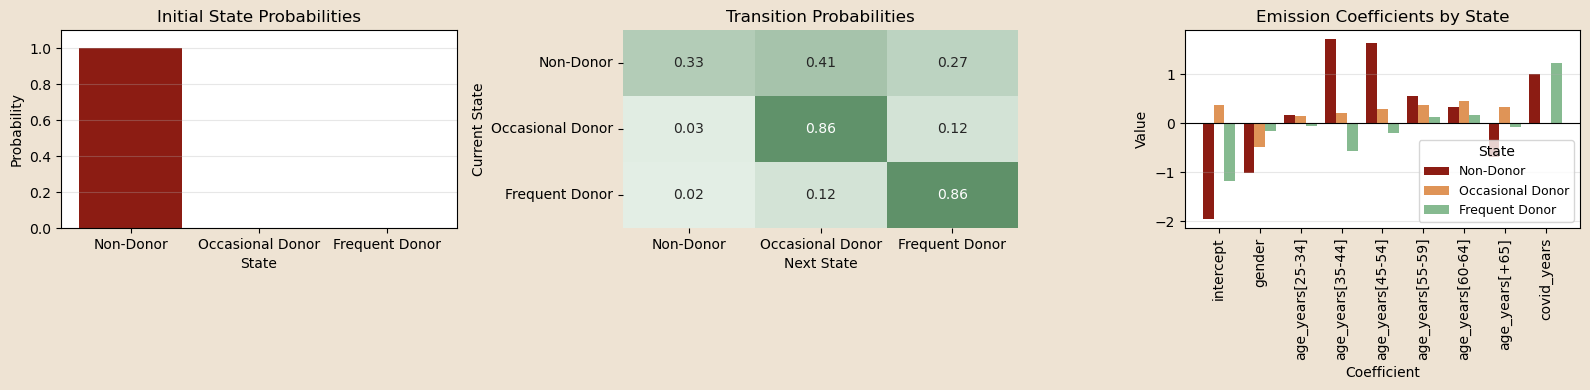

In [60]:
def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# 2) Covariate means
x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)

# 3) Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel() # ravel flats the dimensions from (1,N) to (N)

K = pi_mean.shape[0]
A_mean = np.zeros((K, K))
for k in range(K):
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
    A_mean[k] = softmax_row(logits_row[None, :]).ravel()

state_names = {
    0: "Non-Donor",
    1: "Occasional Donor",
    2: "Frequent Donor",
}

plots = hmm_pl.plot_hmm_params_with_coeffs(
    transitions=A_mean,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=state_names.values(),
    coeff_names=cov_names_em,
    show=True    
)

# Diagnostics


## Viterbi Algorithm (with covariates and Poisson-GLM emissions)

**Goal**: For each donor $n=1..N$, find the MAP latent path $z_{0:T}^\ast$.

**Parameterization (plug-in, posterior means)**
- Covariate-dependent initial distribution:
  - Logits for $\pi$: $\ell_\pi(x_\pi) = \log \pi_{\text{base}} + W_\pi x_\pi$
  - $\pi(x_\pi) = \text{softmax}(\ell_\pi(x_\pi))$
- Covariate-dependent transition matrix:
  - Logits for $A$ at time $t$: $\ell_A(x_{A,t})_{k\to j} = \log A_{\text{base}}[k,j] + \langle W_A[k,j,:], x_{A,t} \rangle$
  - $A(x_{A,t})[k,\cdot] = \text{softmax}_j\bigl(\ell_A(x_{A,t})_{k\to j}\bigr)$
- Emissions:
  - Poisson-GLM per state $k$: $\eta_k(t) = \beta_{em,k,0} + x_{\text{em},t}^T \beta_{em,k}$
  - $\lambda_k(t) = \exp\bigl(\eta_k(t)\bigr)$

**Dynamic Programming**
- Initialization ($t=0$):

$$
\delta_0(k)=\log \pi_k(x_\pi)+\log \text{Poisson}(y_0\mid \lambda_k(0)).
$$

- Recursion for $t=1,\dots,T$:

$$
\delta_t(j)=\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr]+\log \text{Poisson}(y_t\mid \lambda_j(t)),
$$

$$
\psi_t(j)=\arg\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr].
$$

- Back-tracking:

$$
z_T^\ast=\arg\max_k \delta_T(k),
$$

$$
z_{t-1}^\ast=\psi_t\bigl(z_t^\ast\bigr)\quad\text{for }t=T,\dots,1.
$$


In [61]:
import hmm_glm_viterbi as viterbi

paths = viterbi.viterbi_paths_glm(
    obs_torch,
    cov_init_torch,    # (N,C_pi)
    cov_tran_torch,    # (N,T,C_A)
    cov_emiss_torch,    # (N,T,C_em)
    here("models/hmm_glm_improved.pt")
)
switch_rate = (paths[:, 1:] != paths[:, :-1]).any(1).float().mean()
print(f"switch rate = {switch_rate:.2%}")

switch rate = 100.00%


## State occupancy over time (population view)

Looking the plot, it's easy to detect a strong movement from state 0 to state 1 during the covid years. 

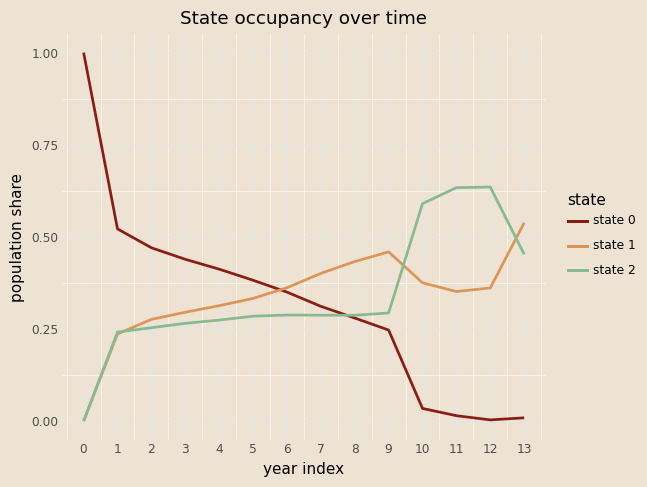

In [62]:
# it works for torch and numpy elements
paths_np = paths.detach().cpu().numpy() if hasattr(paths, "detach") else np.asarray(paths)
N, T = paths_np.shape
K = int(paths_np.max()) + 1 if paths_np.size else 1

# Counts per state over time -> (K,T)
counts = np.stack([(paths_np == k).sum(axis=0) for k in range(K)], axis=0)
props = counts / np.maximum(counts.sum(axis=0, keepdims=True), 1)  # avoid div-by-zero

rows = []
for k in range(K):
    for t in range(T):
        rows.append({"t": t, "state": f"state {k}", "share": float(props[k, t])})
occupancy = pd.DataFrame(rows)

(
    pn.ggplot(occupancy, pn.aes("t", "share", color="state"))
    + pn.geom_line(size=1.1)
    + pn.scale_color_manual(values=state_cols, name="state")
    + pn.scale_x_continuous(breaks=list(range(T)))
    + pn.scale_y_continuous(limits=(0, 1))
    + pn.labs(x="year index", y="population share", title="State occupancy over time")
    + pn.theme_minimal()
    + pn.theme(axis_text_x=pn.element_text(rotation=0))
)

## Individual trajectories

Pick a few donors and overlay observations + decoded state for an easy interpretation of the model.

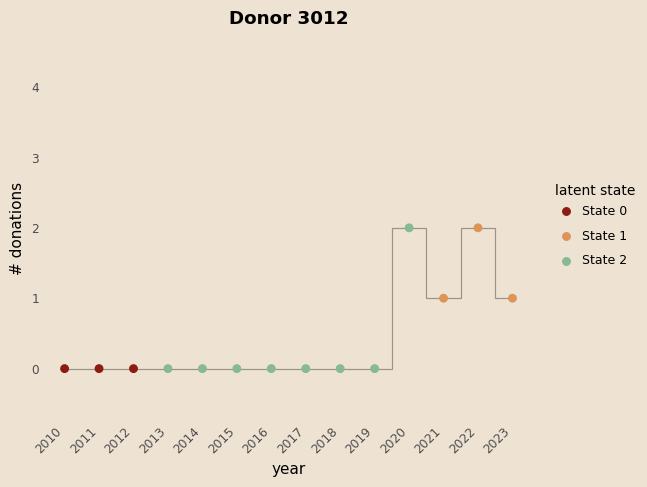

In [63]:
yticks_vals = np.arange(0, 5)

hmm_pl.plot_one_gg(
        idx=3012,
        obs_torch=obs_torch,
        paths=paths,
        years=years_num,
        state_cols=None,
        y_max=4
    )

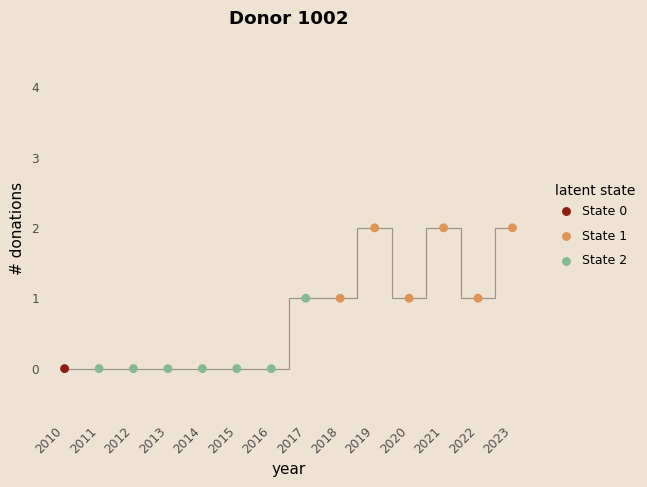

In [64]:
hmm_pl.plot_one_gg(
        idx=1002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_num,
        state_cols=None,
        y_max=4
    )

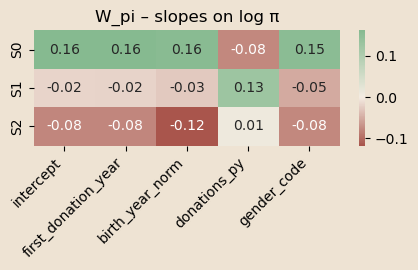

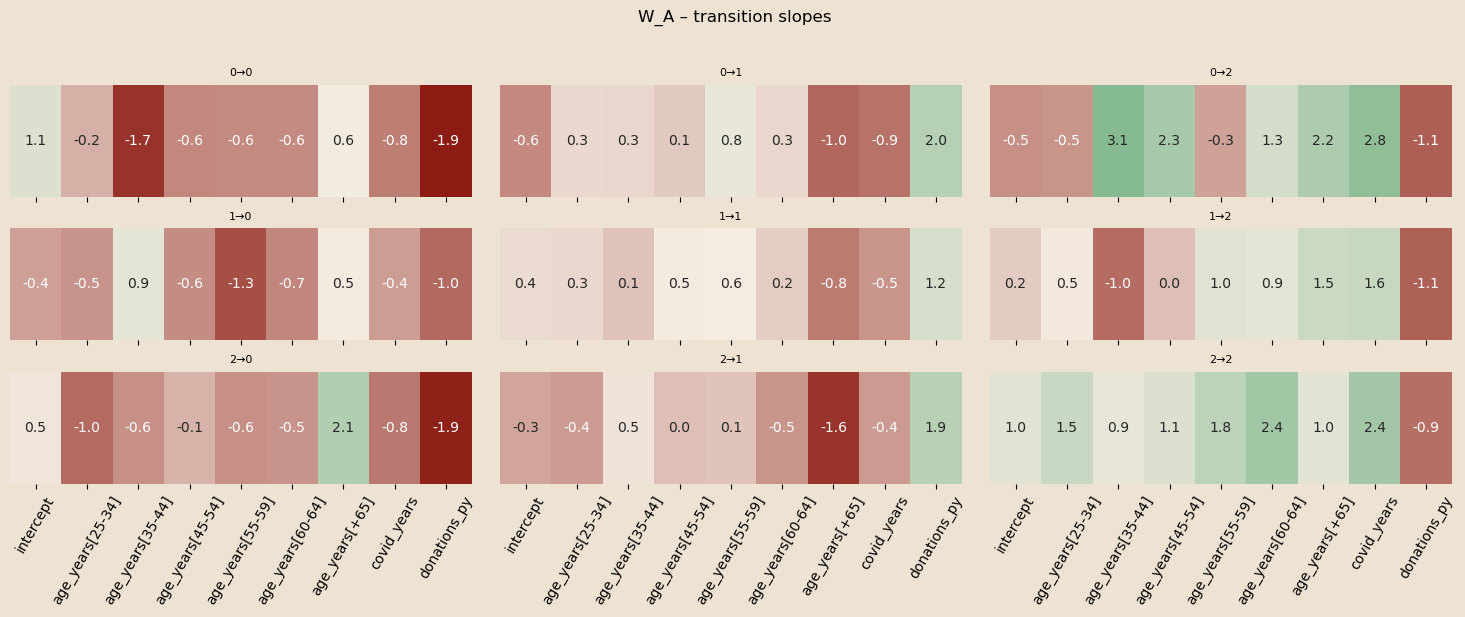

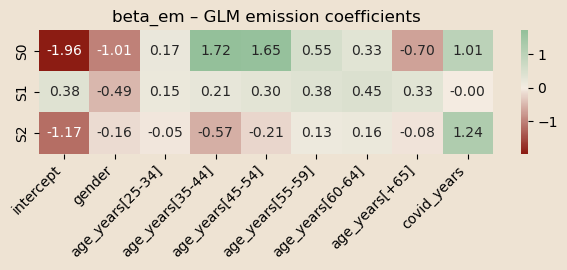

In [65]:
hmm_pl.plot_W_pi_heat(W_pi, cov_names_pi)
hmm_pl.plot_W_A_heat(W_A, cov_names_A)
hmm_pl.plot_beta_em_heat(beta_em, cov_names_em)

## Covariates

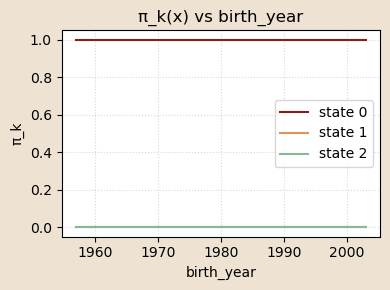

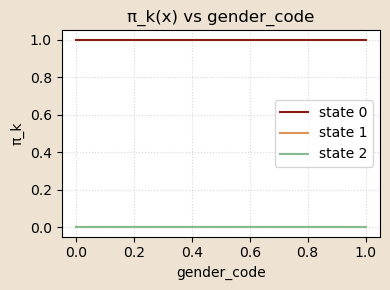

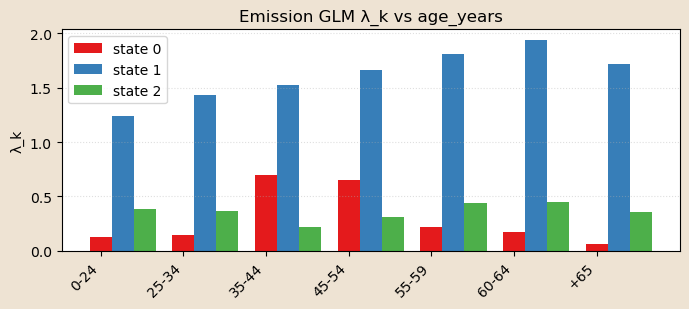

In [66]:
factor_specs_pi = {}

def levels_from_cov_names(cov_names, factor):
    pref = f"{factor}["
    return [c[c.find("[")+1:-1] for c in cov_names if c.startswith(pref) and c.endswith("]")]
present_levels = levels_from_cov_names(cov_names_em, "age_years")
ref_level = "0-24" if "0-24" not in present_levels else None

age_levels_used = ([ref_level] if ref_level is not None else []) + present_levels

factor_specs_em = {
    "age_years": {
        "levels": age_levels_used,
        "ref": ref_level
    },
    "covid_years": {
        "levels:"
    }
}

# cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

# cov_names_em = ["gender_code"] + [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

log_pi0 = np.log(np.clip(pi_base, 1e-30, None))


hmm_pl.plot_pi_vs_cov_orig(
    df=df,
    ages=ages,
    var="birth_year_norm",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=cov_init,
    factor_specs_pi=factor_specs_pi
)

# π_k(x) vs gender_code (binaria)
hmm_pl.plot_pi_vs_cov_orig(
    df=df,
    ages=ages,
    var="gender_code",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=cov_init,
    factor_specs_pi=factor_specs_pi
)

# λ_k(emissione) vs age_years (fattore con 7 livelli)
# print(cov_names_em)

hmm_pl.plot_lambda_em_vs_cov(
    var_em="age_years",
    beta_em=beta_em,
    cov_names_em=cov_names_em,
    x_em_data=cov_emission,
    factor_specs_em=factor_specs_em    # levels=age_levels, ref=None
)


# Train and test

Let's split the DB into 2 parts, one will be used for the training and the other one for the testing.
After the training of the model the test part will be used to get the probabilities about the donor and its donation the next year. 
Furthermore, we want to analyze the past latent state of the person.

In [67]:
@config_enumerate
def model_2(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # 1) Priors/parameters for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))          # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1)) # [K, K]
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # 2) Slope coefficients for initial and transition covariates (learned)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))                  # [K, C_pi]
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))                 # [K, K, C_A]

    # 3) State-specific GLM emission coefficients (learned)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em))        # [K, C_em+1] (intercept + 9 dummies)

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)                      # [N, K]
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: state-specific GLM on covariates x_em[:, 0, :]
        log_mu0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]                                      # [N, C_A]
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))     # [N, K]
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission: state-specific GLM at time t
            log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
def guide_2(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        torch.tensor([0.6, 0.3, 0.1]),
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))


In [68]:
# pyro.clear_param_store()
# svi = SVI(model_2, guide_2, Adam({"lr": 5e-1}), loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(200):
#     loss = svi.step(obs_train, xpi_train, xA_train, cov_emission_train)
#     if step % 20 == 0:
#         print(f"{step:4d}  ELBO(train) = {loss:,.0f}")

# # save the model
# pyro.get_param_store().save(here("models/hmm_glm_improved_train.pt"))
# print("Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map")

Load the model and store the parameters

In [69]:
W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here("models/hmm_glm_improved_train.pt"))


In [70]:
def log_softmax_logits(logits, dim=-1):
    return logits - torch.logsumexp(logits, dim=dim, keepdim=True)


@torch.no_grad()
def forward_loglik_cov(obs, x_pi, x_A, x_em, model_path="models/hmm_glm_improved_train.pt"):
    device = obs.device

    W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here(model_path))
    order = hmm_glm._simple_order_by_pi0(pi_base)
    pi_base, A_base, W_pi, W_A, beta_em, _ = hmm_glm.reorder_params(order, pi_base, A_base, W_pi, W_A, beta_em)

    W_pi    = torch.as_tensor(W_pi,    device=device, dtype=torch.float32)
    W_A     = torch.as_tensor(W_A,     device=device, dtype=torch.float32)
    pi_base = torch.as_tensor(pi_base, device=device, dtype=torch.float32)
    A_base  = torch.as_tensor(A_base,  device=device, dtype=torch.float32)
    beta_em = torch.as_tensor(beta_em, device=device, dtype=torch.float32)

    N, T = obs.shape
    B  = beta_em
    log_mu = torch.einsum("ntc,kc->ntk", x_em, B)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)
    log_alpha = log_pi + emis_log[:, 0]

    log_A0 = A_base.log()
    for t in range(1, T):
        x_t = x_A[:, t, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)
        log_alpha = torch.logsumexp(log_alpha.unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    return torch.logsumexp(log_alpha, dim=1)


@torch.no_grad()
def one_step_ahead_metrics(obs, x_pi, x_A, x_em, model_path="models/hmm_glm_improved_train.pt"):
    import numpy as np
    device = obs.device

    W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here(model_path))
    order = hmm_glm._simple_order_by_pi0(pi_base)
    pi_base, A_base, W_pi, W_A, beta_em, _ = hmm_glm.reorder_params(order, pi_base, A_base, W_pi, W_A, beta_em)

    W_pi    = torch.as_tensor(W_pi,    device=device, dtype=torch.float32)
    W_A     = torch.as_tensor(W_A,     device=device, dtype=torch.float32)
    pi_base = torch.as_tensor(pi_base, device=device, dtype=torch.float32)
    A_base  = torch.as_tensor(A_base,  device=device, dtype=torch.float32)
    beta_em = torch.as_tensor(beta_em, device=device, dtype=torch.float32)

    N, T = obs.shape
    K = pi_base.shape[0]
    B  = beta_em
    log_mu = torch.einsum("ntc,kc->ntk", x_em, B)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)
    log_alpha = torch.empty(N, T, K, device=device)
    log_alpha[:, 0] = log_pi + emis_log[:, 0]
    alpha_norm = (log_alpha[:, 0] - torch.logsumexp(log_alpha[:, 0], dim=1, keepdim=True)).exp()

    preds_mean, preds_pdon, logscore, y_next_all = [], [], [], []
    log_A0 = A_base.log()

    for t in range(0, T - 1):
        x_t1 = x_A[:, t + 1, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t1[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)

        P_next = torch.exp(torch.log(alpha_norm + 1e-40).unsqueeze(1) + log_A).sum(dim=2)
        log_mu_t1 = torch.einsum("nc,kc->nk", x_em[:, t + 1, :], B)
        lam_ntk = log_mu_t1.exp()

        Ey  = (P_next * lam_ntk).sum(dim=1)
        P0  = (P_next * torch.exp(-lam_ntk)).sum(dim=1)
        Pdon = 1.0 - P0

        y_next = obs[:, t + 1]
        pmf_k = torch.stack([torch.exp(dist.Poisson(lam_ntk[:, k]).log_prob(y_next)) for k in range(K)], dim=1)
        mix_pmf = (P_next * pmf_k).sum(dim=1).clamp_min(1e-12)
        ls = torch.log(mix_pmf)

        preds_mean.append(Ey.cpu().numpy())
        preds_pdon.append(Pdon.cpu().numpy())
        logscore.append(ls.cpu().numpy())
        y_next_all.append(y_next.cpu().numpy())

        log_alpha[:, t + 1] = torch.logsumexp(log_alpha[:, t].unsqueeze(2) + log_A, dim=1) + emis_log[:, t + 1]
        alpha_norm = (log_alpha[:, t + 1] - torch.logsumexp(log_alpha[:, t + 1], dim=1, keepdim=True)).exp()

    Ey = np.concatenate(preds_mean)
    Pd = np.concatenate(preds_pdon)
    LS = np.concatenate(logscore)
    Y  = np.concatenate(y_next_all)

    mae = np.mean(np.abs(Ey - Y))
    rmse = np.sqrt(np.mean((Ey - Y) ** 2))
    brier = np.mean((Pd - (Y > 0).astype(float)) ** 2)
    nll = -np.mean(LS)
    return {"MAE": mae, "\nRMSE": rmse, "\nBrier(y>0)": brier, "\nNLL": nll}

In [71]:
# TODO #4 move to GPU
# Now we're using CPU, but in the future would be nice to swith to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

obs_test_d  = obs_test.to(device)
xpi_test_d  = xpi_test.to(device)
xA_test_d   = xA_test.to(device)
xem_test_d  = cov_emission_test.to(device)

ll_test = forward_loglik_cov(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d, model_path="models/hmm_glm_improved_train.pt")
print(f"Test mean log-likelihood per seq: {ll_test.mean().item():.3f}")

metrics = one_step_ahead_metrics(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d, model_path="models/hmm_glm_improved_train.pt")
print("One-step-ahead metrics (test):", metrics)

obs_train_d = obs_train.to(device)
xpi_train_d = xpi_train.to(device)
xA_train_d  = xA_train.to(device)
xem_train_d = cov_emission_train.to(device)

ll_train = forward_loglik_cov(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d, model_path="models/hmm_glm_improved_train.pt")
metrics_tr = one_step_ahead_metrics(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d, model_path="models/hmm_glm_improved_train.pt")
print(f"Train mean log-likelihood per seq: {ll_train.mean().item():.3f}")
print("One-step-ahead metrics (train):", metrics_tr)

Test mean log-likelihood per seq: -13.236
One-step-ahead metrics (test): {'MAE': np.float64(0.8972521653803817), '\nRMSE': np.float64(1.141930748667273), '\nBrier(y>0)': np.float64(0.38267585214294797), '\nNLL': np.float32(0.9892887)}
Train mean log-likelihood per seq: -13.378
One-step-ahead metrics (train): {'MAE': np.float64(0.893028232163754), '\nRMSE': np.float64(1.1319402820487052), '\nBrier(y>0)': np.float64(0.3864647731849321), '\nNLL': np.float32(0.98787963)}


In [72]:
def _softmax_row(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)


@torch.no_grad()
def predict_donor(
    birth_year: int,
    gender: str,
    history_years: list,
    history_counts: list,
    next_year: int | None = None,
    max_k: int = 4,
    covid_years=(2020, 2021, 2022),
    model_path="models/hmm_glm_train.pt"
):
    years = np.array(history_years, dtype=int)
    yvals = np.array(history_counts, dtype=int)
    if next_year is None:
        next_year = int(years[-1] + 1)

    W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here(model_path))
    order = hmm_glm._simple_order_by_pi0(pi_base)
    pi_base, A_base, W_pi, W_A, beta_em, inv = hmm_glm.reorder_params(order, pi_base, A_base, W_pi, W_A, beta_em)

    K = int(pi_base.shape[0])

    g_code = 1.0 if gender.upper().startswith("F") else 0.0
    by_norm = (birth_year - birth_year_mean) / birth_year_std

    age_bins = np.array([18, 25, 35, 45, 55, 60, 65, 75])
    ages_arr = years - birth_year
    ages_binned = np.digitize(ages_arr, age_bins, right=False)
    n_agebins = len(age_bins) - 1
    ages_binned = np.clip(ages_binned, 1, n_agebins)
    ages_onehot = np.eye(n_agebins)[ages_binned - 1][:, 1:]
    covid_flag = np.isin(years, covid_years).astype(float)[:, None]

    x_pi_np = np.array([[1.0, by_norm, g_code]], dtype=np.float32)
    intercept = np.ones((len(years), 1), dtype=np.float32)

    x_A_hist = np.concatenate([intercept, ages_onehot.astype(np.float32), covid_flag.astype(np.float32)], axis=1)
    age_next = np.array([next_year - birth_year])
    ages_binned_next = np.digitize(age_next, age_bins, right=False)
    ages_binned_next = np.clip(ages_binned_next, 1, n_agebins)
    ages_onehot_next = np.eye(n_agebins)[ages_binned_next - 1][:, 1:]
    covid_next_flag = np.array([[1.0 if next_year in covid_years else 0.0]], dtype=np.float32)
    x_A_next = np.concatenate([np.ones((1,1), dtype=np.float32), ages_onehot_next.astype(np.float32), covid_next_flag], axis=1)[0]

    gender_col = np.full((len(years), 1), g_code, dtype=np.float32)
    x_em_hist = np.concatenate([intercept, gender_col, ages_onehot.astype(np.float32), covid_flag.astype(np.float32)], axis=1)
    x_em_next = np.concatenate([np.ones((1,1), dtype=np.float32), np.array([[g_code]], dtype=np.float32), ages_onehot_next.astype(np.float32), covid_next_flag], axis=1)[0]

    obs_te  = torch.tensor(yvals[None, :], dtype=torch.long)
    xpi_te  = torch.tensor(x_pi_np, dtype=torch.float32)
    xA_te   = torch.tensor(x_A_hist[None, :, :], dtype=torch.float32)
    xem_te  = torch.tensor(x_em_hist[None, :, :], dtype=torch.float32)

    paths_old = viterbi.viterbi_paths_glm(obs_te, xpi_te, xA_te, xem_te, model_path=here(model_path))
    v_path = inv[paths_old.cpu().numpy()[0]].tolist()

    B = torch.tensor(beta_em, dtype=torch.float32)
    emis_log = dist.Poisson(rate=torch.einsum("ntc,kc->ntk", xem_te, B).exp()).log_prob(obs_te.unsqueeze(-1))

    log_pi0 = torch.tensor(np.log(pi_base + 1e-30) + (x_pi_np @ W_pi.T), dtype=torch.float32)
    log_pi = log_pi0 - torch.logsumexp(log_pi0, dim=1, keepdim=True)

    K = pi_base.shape[0]
    T_hist = obs_te.size(1)
    log_alpha = torch.empty(1, T_hist, K, dtype=torch.float32)
    log_alpha[:, 0] = log_pi + emis_log[:, 0]

    logA0 = torch.tensor(np.log(A_base + 1e-30), dtype=torch.float32)
    W_A_t = torch.tensor(W_A, dtype=torch.float32)
    for t in range(1, T_hist):
        x_t = xA_te[:, t, :]
        logits = logA0.unsqueeze(0) + (W_A_t.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)
        log_A  = logits - torch.logsumexp(logits, dim=2, keepdim=True)
        log_alpha[:, t] = torch.logsumexp(log_alpha[:, t - 1].unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    alpha_T = (log_alpha[:, -1] - torch.logsumexp(log_alpha[:, -1], dim=1, keepdim=True)).exp().cpu().numpy()[0]

    logits_next = np.log(A_base + 1e-30) + np.tensordot(W_A, x_A_next, axes=([2], [0]))
    A_next = _softmax_row(logits_next)
    p_next = alpha_T @ A_next

    lam_next = np.exp(beta_em @ x_em_next)
    expected_next = float((p_next * lam_next).sum())
    p0 = float((p_next * np.exp(-lam_next)).sum())
    prob_donate_next = 1.0 - p0

    from scipy.stats import poisson as _po
    pmf0k = np.array([(p_next * _po.pmf(k, lam_next)).sum() for k in range(max_k + 1)], dtype=float)
    tail  = float(max(0.0, 1.0 - pmf0k.sum()))
    pmf_dict = {str(k): float(pmf0k[k]) for k in range(max_k + 1)}
    pmf_dict[f">={max_k+1}"] = tail

    return {
        "years": history_years,
        "counts": history_counts,
        "viterbi_states": v_path,
        "next_year": int(next_year),
        "next_state_probs": p_next.tolist(),
        "expected_next": expected_next,
        "prob_donate_next": prob_donate_next,
        "pmf_next": pmf_dict
    }

In [73]:
# stats = np.load("norm_stats.npz")
# birth_year_mean = float(stats["birth_year_mean"])
# birth_year_std  = float(stats["birth_year_std"])
# ages_mean       = float(stats["ages_mean"])
# ages_std        = float(stats["ages_std"])

birth_year = 1985
gender = "F"
history_years   = list(range(2009, 2024))
history_counts  = [0,1,0,0,1,0,0,1,0,0,1,0,1,0,0]
next_year = 2024

out = predict_donor(
    birth_year=birth_year,
    gender=gender,
    history_years=history_years,
    history_counts=history_counts,
    next_year=next_year,
    max_k=4,
    model_path="models/hmm_glm_train.pt"
)

print("Years:", out["years"])
print("Counts:", out["counts"])
print("Viterbi states:", out["viterbi_states"])
print("Next year:", out["next_year"])
print("Next-state probabilities:", np.round(out["next_state_probs"], 3))
print("Expected next:", round(out["expected_next"], 3))
print("Prob donate next:", round(out["prob_donate_next"], 3))
print("PMF next:", {k: round(v, 4) for k, v in out["pmf_next"].items()})

Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Counts: [0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]
Viterbi states: [0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Next year: 2024
Next-state probabilities: [0.108 0.016 0.876]
Expected next: 0.565
Prob donate next: 0.417
PMF next: {'0': 0.5828, '1': 0.2984, '2': 0.0946, '3': 0.0203, '4': 0.0034, '>=5': 0.0005}


Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Counts: [0, 0, 3, 4, 3, 4, 3, 4, 3, 2, 2, 2, 3]
Viterbi states: [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Next year: 2023
Next-state probabilities: [0.005 0.87  0.125]
Expected next: 1.869
Prob donate next: 0.824
PMF next: {'0': 0.1761, '1': 0.2758, '2': 0.2527, '3': 0.1643, '4': 0.0822, '>=5': 0.0489}


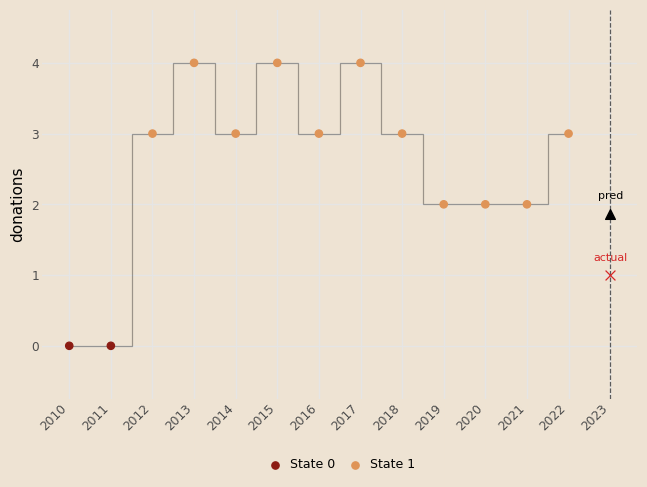

In [74]:
i = 4011
years_hist = years_num[:-1].tolist()
year_next  = int(years_num[-1])
counts_hist = obs_torch[i, :len(years_hist)].detach().cpu().numpy().tolist()

birth_year_i = int(df["birth_year"][i])
gender_i     = df["gender"][i]

pred = predict_donor(
    birth_year=birth_year_i,
    gender=gender_i,
    history_years=years_hist,
    history_counts=counts_hist,
    next_year=year_next,
    max_k=4,
    model_path="models/hmm_glm_train.pt"
)

T_hist = len(years_hist)
N = obs_torch.shape[0]
paths = np.zeros((N, T_hist), dtype=int)
paths[i, :] = np.asarray(pred["viterbi_states"], dtype=int)

print("Years:", pred["years"])
print("Counts:", pred["counts"])
print("Viterbi states:", pred["viterbi_states"])
print("Next year:", pred["next_year"])
print("Next-state probabilities:", np.round(pred["next_state_probs"], 3))
print("Expected next:", round(pred["expected_next"], 3))
print("Prob donate next:", round(pred["prob_donate_next"], 3))
print("PMF next:", {k: round(v, 4) for k, v in pred["pmf_next"].items()})

y_true_next = int(obs_torch[i, T_hist].detach().cpu().item())
p = hmm_pl.plot_donor_gg(
    idx=i,
    obs_torch=obs_torch[:, :T_hist],
    paths=paths,
    years=years_hist,
    expected_next=pred["expected_next"],
    y_true_next=y_true_next,
    next_year=year_next,
    y_max=4
)
p

# Comparison with a GLM

## GLM Poisson in Pyro

Let's define a vanilla GLM to check the results versus our model. 
Even thought is a easy model and it could be defined manually, or with simpler libraries, we decided to define it via Pyro.

- $y \sim \mathrm{Poisson}(\mu)$
- $\log \mu = \beta_0 + \beta_1 \text{birth\_year\_norm} + \beta_2 \text{gender}$

In [75]:
from pyro.infer import Trace_ELBO
# Poisson GLM with log link
def glm_poisson_model(X, y=None, param_name="glm_beta"):
    N, C = X.shape
    beta = pyro.param(param_name, torch.zeros(C, device=X.device))  # intercept + C slopes
    log_mu = (X @ beta[:].unsqueeze(-1)).squeeze(-1)         # (N,)
    mu = log_mu.exp()
    with pyro.plate("data", N):
        pyro.sample("obs", dist.Poisson(mu), obs=y)

def glm_poisson_guide(X, y=None, param_name="glm_beta"):
    # Mean-field guide is empty: we use point estimates via pyro.param in the model.
    pass

# Train
def fit_glm_poisson(X, y, steps=3000, lr=1e-2, param_name="glm_beta", verbose_every=500, save_path=here("python/glm_poisson_improved_params.pt")):
    X = X.detach()
    y = y.detach().float()
    pyro.clear_param_store()
    svi = SVI(
        lambda X_, y_: glm_poisson_model(X_, y_, param_name),
        lambda X_, y_: glm_poisson_guide(X_, y_, param_name),
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )
    loss_hist = []
    for s in range(steps):
        loss = svi.step(X, y)
        if verbose_every and s % verbose_every == 0:
            print(f"step {s:4d}: loss={loss:.3f}")
        loss_hist.append(loss)
    pyro.get_param_store().save(save_path)
    return loss_hist

# Predict and metrics
@torch.no_grad()
def glm_poisson_predict(X, param_name="glm_beta", return_proba=True):
    X = X.detach()
    beta = pyro.param(param_name)
    log_mu = (X @ beta[:].unsqueeze(-1)).squeeze(-1)
    mu = log_mu.exp()  # expected counts
    if return_proba:
        p_donate = 1.0 - torch.exp(-mu)  # P(Y>0 | mu)
        return mu, p_donate
    return mu

@torch.no_grad()
def glm_poisson_evaluate_hmmstyle(X, y, param_name="glm_beta", return_all=False):
    """
    Metrics aligned with the HMM printout:
      - pred mean
      - obs mean
      - MSE
      - Accuracy (round)

    If return_all=True, also returns MAE, RMSE, NLL, Brier(y>0).
    """
    X = X.detach()
    y_f = y
    mu = glm_poisson_predict(X, param_name, return_proba=False)  # (N,)

    # HMM-style metrics
    pred_mean = mu.mean().item()
    obs_mean  = y_f.mean().item()
    mse = torch.mean((mu - y_f) ** 2).item()
    acc_round = torch.mean((torch.round(mu) == y_f).float()).item()

    out = {
        "pred mean": pred_mean,
        "obs mean": obs_mean,
        "MSE": mse,
        "Accuracy (round)": acc_round,
    }

    if return_all:
        mae = torch.mean(torch.abs(mu - y_f)).item()
        rmse = torch.sqrt(torch.mean((mu - y_f) ** 2)).item()
        nll = -torch.mean(dist.Poisson(mu).log_prob(y_f)).item()
        brier = torch.mean(((1.0 - torch.exp(-mu)) - (y_f > 0).float()) ** 2).item()
        out.update({"MAE": mae, "\nRMSE": rmse, "\nNLL": nll, "\nBrier(y>0)": brier})

    return out

In [76]:
# y_train: last-year counts, X_train: corresponding covariates
y_train = obs_train[:, -1].float()
X_train = cov_emission_train[:, -1, :]

y_test = obs_test[:, -1].float()
X_test = cov_emission_test[:, -1, :]

loss_hist = fit_glm_poisson(X_train, y_train, steps=100, lr=1e-1, verbose_every=10)
y_pred_glm = glm_poisson_predict(X_test)

step    0: loss=10976.531
step   10: loss=10665.809
step   20: loss=10634.096
step   30: loss=10634.699
step   40: loss=10632.379
step   50: loss=10631.116
step   60: loss=10630.670
step   70: loss=10630.494
step   80: loss=10630.465
step   90: loss=10630.464


## Evaluation

Save and load the model

In [77]:
pyro.get_param_store().load(here("python/glm_poisson_improved_params.pt"))
metrics_glm = glm_poisson_evaluate_hmmstyle(X_test, y_test)
print(f"GLM: pred mean={metrics_glm['pred mean']:.2f}  obs mean={metrics_glm['obs mean']:.2f}")
print(f"MSE: {metrics_glm['MSE']:.4f}")
print(f"Accuracy (round): {100*metrics_glm['Accuracy (round)']:.2f}%")

GLM: pred mean=0.96  obs mean=0.99
MSE: 1.0736
Accuracy (round): 27.96%


## Prediction with HMM

In [78]:
EPS = 1e-30

def softmax_row(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

def hmm_forward_predict(
    obs_so_far, xpi, xA, A_base, W_pi, W_A, pi_base, beta_em, cov_emission,
    steps_ahead=1,
    pick_one_state=False,
):
    """
    Predicts E[y_{T+steps_ahead}] with covariate-driven transitions and GLM emissions.

    Parameters
    ----------
    obs_so_far : (N, T_obs) array or None
        Observed history (used only for its length; no filtering).
    xpi : (N, C_pi) float
        Initial-state covariates.
    xA : (N, T_total, C_A) float
        Transition covariates for all times (must cover prediction index).
    A_base : (K, K) float, rows simplex
        Base transition matrix.
    W_pi : (K, C_pi) float
        Initial-state slopes.
    W_A : (K, K, C_A) float
        Transition slopes (row-wise).
    pi_base : (K,) float, simplex
        Base initial state.
    beta_em : (K, 1 + C_em) float
        Emission GLM coefficients (intercept + slopes) per state.
    cov_emission : (N, T_total, C_em) float
        Emission covariates at each time.
    steps_ahead : int
        How many steps ahead from T_obs to predict (>=1).
    pick_one_state : boolean
        Pick from last state the most probable or take the entire distribution

    Returns
    -------
    y_expected : (N,) float
        Predicted expected donations at prediction time.
    state_dist : (N, K) float
        Belief on hidden state at prediction time (after propagation).
    """
    N = xpi.shape[0]
    T_obs = 0 if (obs_so_far is None) else int(obs_so_far.shape[1])

    # 1) Initial alpha via softmax(log π_base + xπ Wπ^T)
    logits_pi = np.log(pi_base + EPS)[None, :] + xpi @ W_pi.T            # (N,K)
    alpha = softmax_row(logits_pi)                                       # (N,K)

    # 2) Propagation for steps_ahead
    #    For each t in [T_obs, T_obs+steps_ahead-1] build Aprob(n) = softmax_row(log A_base + W_A ⋅ xA[n,t,:])
    logA0 = np.log(A_base + EPS)                                         # (K,K)
    for t in range(T_obs, T_obs + steps_ahead):
        x_t = xA[:, t, :]                                                # (N,C_A)
        # slope logits: tensordot over C_A → (N,K,K)
        slope = np.tensordot(x_t, W_A, axes=([1], [2]))                  # (N,K,K)
        logits = logA0[None, :, :] + slope                               # (N,K,K)
        Aprob = softmax_row(logits)                                      # (N,K,K) row-softmax over axis=-1
        alpha = np.einsum('nk,nkj->nj', alpha, Aprob)                    # (N,K)

    # 3) Emission at prediction time
    t_pred = T_obs + steps_ahead - 1
    x_em = cov_emission[:, t_pred, :]                                    # (N,C_em)
    B  = beta_em[:, :]                                                  # (K,C_em)
    eta = x_em @ B.T                                                # (N,K)
    lam = np.exp(eta)                                                    # (N,K)

    # Expected count under mixture
    if pick_one_state:
        # in questo caso considero solo le emissioni dello stato massimo. Si discosta dall'approccio bayesiano ma aumenta la accuracy e peggiora il MAE,RMSE e MSE
        final_state = np.argmax(alpha, axis=1)      # (N,)
        y_expected = lam[np.arange(N), final_state] # (N,)
    else:
        y_expected = (alpha * lam).sum(axis=1)                               # (N,)

    return y_expected, alpha

In [79]:
beta_em.shape
# cov_emission_test_np.shape

(3, 9)

In [80]:
# Carica parametri
#W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

# Converte tensori PyTorch -> NumPy
obs_test_np         = obs_test.detach().cpu().numpy()
xpi_test_np         = xpi_test.detach().cpu().numpy()
xA_test_np          = xA_test.detach().cpu().numpy()
cov_emission_test_np= cov_emission_test.detach().cpu().numpy()

# Predici y_T (one-step ahead) usando osservazioni fino a T-1
y_pred_hmm, state_prob = hmm_forward_predict(
    obs_so_far      = obs_test_np[:, :-1],     # up to T-1
    xpi             = xpi_test_np,
    xA              = xA_test_np,
    A_base          = A_base,
    W_pi            = W_pi,
    W_A             = W_A,
    pi_base         = pi_base,
    beta_em         = beta_em,
    cov_emission    = cov_emission_test_np,    # (N_test, T, C_em)
    steps_ahead     = 1
)

In [81]:
y_test = obs_test_np[:, -1]
print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
print(f"MSE: {np.mean((y_pred_hmm - y_test)**2):.4f}")
print(f"Accuracy (round): {100*np.mean(np.round(y_pred_hmm)==y_test):.2f}%")

HMM(full): pred mean=1.16  obs mean=0.99
MSE: 0.8960
Accuracy (round): 42.47%


In [82]:
def _to_numpy1d(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x, dtype=float).ravel()

def build_hmm_metrics(y_pred_hmm, y_test):
    y_pred = _to_numpy1d(y_pred_hmm)
    y_true = _to_numpy1d(y_test)
    return {
        "pred mean": float(np.mean(y_pred)),
        "obs mean":  float(np.mean(y_true)),
        "MSE":       float(np.mean((y_pred - y_true) ** 2)),
        "Accuracy (round)": float(np.mean(np.round(y_pred) == y_true)),
    }

def pct_rel_diff(a, b, eps=1e-12):
    return 100.0 * (a - b) / (abs(b) + eps)

def print_comparison_table(metrics_glm, metrics_hmm):
    print(f"{'Metric':<20} {'GLM':>14} {'HMM':>14} {'Abs diff':>14} {'Rel diff %':>12}")
    print("-" * 76)
    order = ["pred mean", "obs mean", "MSE", "Accuracy (round)"]
    for key in order:
        g = metrics_glm[key]
        h = metrics_hmm[key]
        if key == "Accuracy (round)":
            g_disp = 100.0 * g
            h_disp = 100.0 * h
            abs_disp = 100.0 * (g - h)          # punti percentuali
            rel_pct = pct_rel_diff(g, h)
            print(f"{key:<20} {g_disp:14.2f}% {h_disp:14.2f}% {abs_disp:14.2f}pp {rel_pct:11.2f}%")
        elif key == "MSE":
            abs_diff = g - h
            rel_pct = pct_rel_diff(g, h)
            print(f"{key:<20} {g:14.4f} {h:14.4f} {abs_diff:14.4f} {rel_pct:11.2f}%")
        else:
            abs_diff = g - h
            rel_pct = pct_rel_diff(g, h)
            print(f"{key:<20} {g:14.2f} {h:14.2f} {abs_diff:14.2f} {rel_pct:11.2f}%")

In [83]:
metrics_hmm = build_hmm_metrics(y_pred_hmm, y_test)

print_comparison_table(metrics_glm, metrics_hmm)

Metric                          GLM            HMM       Abs diff   Rel diff %
----------------------------------------------------------------------------
pred mean                      0.96           1.16          -0.20      -17.19%
obs mean                       0.99           0.99           0.00        0.00%
MSE                          1.0736         0.8960         0.1777       19.83%
Accuracy (round)              27.96%          42.47%         -14.52pp      -34.18%


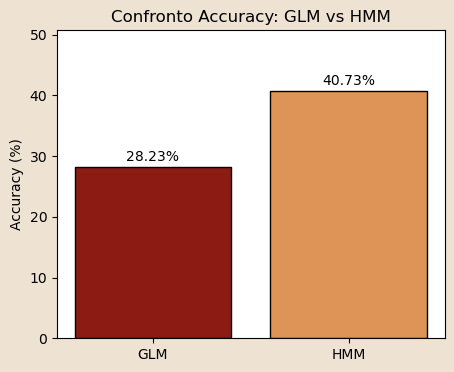

In [84]:
def plot_accuracy(glm_acc, hmm_acc):
    """
    Plotta le accuracy di GLM e HMM.
    
    Args:
        glm_acc (float): Accuracy del GLM (in percento o frazione).
        hmm_acc (float): Accuracy dell'HMM (in percento o frazione).
    """
    # Se i valori sono frazioni (0-1), li porto in percento
    if glm_acc <= 1 and hmm_acc <= 1:
        glm_acc *= 100
        hmm_acc *= 100
    
    methods = ["GLM", "HMM"]
    values = [glm_acc, hmm_acc]

    plt.figure(figsize=(5,4))
    bars = plt.bar(methods, values, color=hmm_pl.palette, edgecolor="black")
    
    # Aggiungo etichette sopra le barre
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.2f}%", 
                 ha="center", va="bottom", fontsize=10)
    
    plt.ylabel("Accuracy (%)")
    plt.title("Confronto Accuracy: GLM vs HMM")
    plt.ylim(0, max(values) + 10)
    plt.show()

#plot_accuracy(metrics_glm["Accuracy (round)"], metrics_hmm["Accuracy (round)"]) 
plot_accuracy(28.23, 40.73)  # esempio con valori fittizi   

In [85]:
# Carica parametri
#W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

# Converte tensori PyTorch -> NumPy
obs_test_np         = obs_test.detach().cpu().numpy()
xpi_test_np         = xpi_test.detach().cpu().numpy()
xA_test_np          = xA_test.detach().cpu().numpy()
xem_test_np= cov_emission_test.detach().cpu().numpy()

# Predici y_T (one-step ahead) usando osservazioni fino a T-1
y_pred_hmm, state_prob = hmm_forward_predict(
    obs_so_far      = obs_test_np[:, :-1],     # up to T-1
    xpi             = xpi_test_np,
    xA              = xA_test_np,
    A_base          = A_base,
    W_pi            = W_pi,
    W_A             = W_A,
    pi_base         = pi_base,
    beta_em         = beta_em,
    cov_emission    = xem_test_np,    # (N_test, T, C_em)
    steps_ahead     = 1,
    pick_one_state  = False,
)
# take just the most  probable state
y_pred_hmm_one_state, _ = hmm_forward_predict(
    obs_so_far      = obs_test_np[:, :-1],     # up to T-1
    xpi             = xpi_test_np,
    xA              = xA_test_np,
    A_base          = A_base,
    W_pi            = W_pi,
    W_A             = W_A,
    pi_base         = pi_base,
    beta_em         = beta_em,
    cov_emission    = xem_test_np,    # (N_test, T, C_em)
    steps_ahead     = 1,
    pick_one_state  = True,
)

In [86]:
# np.round(y_pred_glm)[1,:]
# y_pred_hmm.shape

In [87]:

df_pred = pd.DataFrame({
    "y_pred_hmm_multi_state": y_pred_hmm,
    "y_pred_hmm_one_state": y_pred_hmm_one_state,
    "y_test": y_test,
    # "y_test": y_test.detach().cpu().numpy().ravel(),
    "y_pred_glm": np.round(y_pred_glm)[1, :],
})
df_pred["error_hmm_ms"] = df_pred["y_pred_hmm_multi_state"].round() - df_pred["y_test"]
df_pred["error_hmm_os"] = df_pred["y_pred_hmm_one_state"].round() - df_pred["y_test"]
df_pred["error_glm"] = df_pred["y_pred_glm"].round() - df_pred["y_test"]
df_pred["error_glm_rounded"] = df_pred["error_glm"].astype(int)
df_pred["error_hmm_ms_rounded"] = df_pred["error_hmm_ms"].astype(int)
df_pred["error_hmm_os_rounded"] = df_pred["error_hmm_os"].astype(int)

df_pred.to_csv(here("models/metrics_df_improved.csv"), index=False)

<positron-console-cell-89>:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


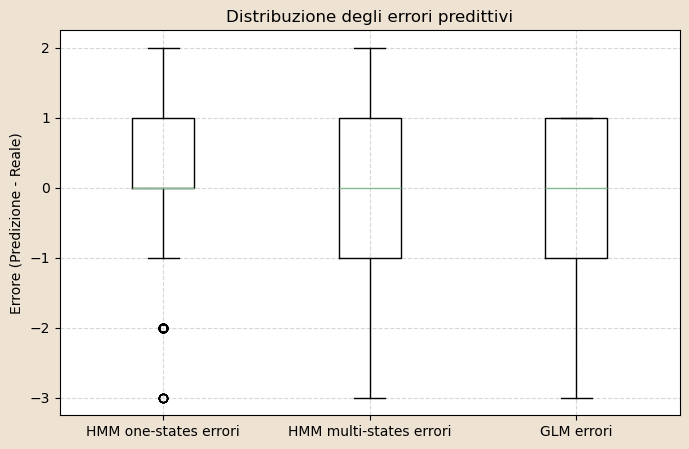

In [88]:
plt.figure(figsize=(8, 5))
plt.boxplot([df_pred["error_hmm_os"],df_pred["error_hmm_ms"], df_pred["error_glm"]], labels=["HMM one-states errori", "HMM multi-states errori", "GLM errori"])
plt.ylabel("Errore (Predizione - Reale)")
plt.title("Distribuzione degli errori predittivi")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()